# Financial Growth - Case 2: Uplift Modeling

## 1. Contexto e problema de negócio

Uma instituição financeira executa campanhas mensais para estimular a contratação de um produto, mas consegue tratar apenas 20% da população elegível. O problema não é prever quem converterá; é decidir **quem converterá por causa da campanha**.

Este notebook implementa uma solução causal end-to-end, da auditoria do experimento à política econômica. A unidade de análise é `customer_id × campaign_wave` e cada cliente aparece uma única vez na base.

**Decisão suportada:** selecionar a audiência mensal que maximiza valor incremental esperado sob restrição de capacidade.

## 2. Pergunta causal, população e janelas

O estimando principal é o efeito condicional Intention-to-Treat:

`CATE(x) = E[Y(1) - Y(0) | X=x]`

- **Population definition:** clientes elegíveis em cada onda randomizada.
- **Treatment:** `treatment_assigned`, definido pela randomização.
- **Outcome:** `conversion_30d`.
- **Decision timestamp:** imediatamente antes da atribuição da campanha.
- **Observation window:** variáveis comportamentais anteriores à `reference_date`.
- **Performance window:** 30 dias posteriores à atribuição.
- **Non-compliance:** `message_delivered` mede execução depois da atribuição e não substitui o tratamento randomizado.

**Comentário Técnico:** a comparação principal permanece assignment versus control. Condicionar em entrega quebraria a randomização e mudaria o estimando.

In [1]:
from pathlib import Path
import json
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

SEED = 20260927
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

print("Project root resolved successfully.")

Project root resolved successfully.


## 3. Carga da base e contrato de dados

Somente dois arquivos públicos entram no pipeline: a base raw e o dicionário. O arquivo privado do DGP não faz parte do repositório e não é lido por este notebook.

In [2]:
raw_path = PROJECT_ROOT / "data" / "raw" / "case_02_uplift_modeling_raw.csv"
dictionary_path = PROJECT_ROOT / "data" / "raw" / "case_02_data_dictionary.csv"

df = pd.read_csv(raw_path)
dictionary = pd.read_csv(dictionary_path)
df["reference_date"] = pd.to_datetime(df["reference_date"])

pd.DataFrame({
    "rows": [len(df)],
    "columns": [df.shape[1]],
    "unique_customers": [df["customer_id"].nunique()],
    "campaign_waves": [df["campaign_wave"].nunique()],
    "duplicate_customer_wave": [df.duplicated(["customer_id", "campaign_wave"]).sum()],
})

,rows,columns,unique_customers,campaign_waves,duplicate_customer_wave
0,300000,60,300000,6,0


**Análise/Interpretação:** a base possui 300 mil clientes únicos, seis ondas equilibradas e nenhuma duplicidade na chave analítica. A estrutura permite validação temporal, mas não um painel longitudinal por cliente.

## 4. Timing das variáveis, leakage e post-treatment bias

As covariáveis do CATE devem existir antes da randomização. `message_delivered`, `channel`, `campaign_cost` e `post_campaign_product_page_views_7d` são pós-atribuição; incluí-las no modelo principal bloquearia ou abriria caminhos causais indevidos.

In [3]:
timing_review = pd.read_csv(PROJECT_ROOT / "outputs" / "tables" / "variable_timing_and_leakage_review.csv")
timing_review.groupby(["measurement_timing", "model_role"]).size().rename("variables").reset_index()

,measurement_timing,model_role,variables
0,assignment,treatment,1
1,outcome,outcome,3
2,post_assignment,excluded post-treatment,4
3,pre_treatment,identifier/time,3
4,pre_treatment,pre-treatment covariate,49


## 5. Partição temporal e disciplina de OOT

- Train: ondas 1 a 4.
- Validation: onda 5.
- OOT Final Test: onda 6.

O champion, as covariáveis, o preprocessing, os hiperparâmetros e a capacidade de 20% são congelados antes da onda 6. O código público grava `champion_freeze_record.json` antes de transformar ou avaliar o OOT.

## 6. Execução integral

A célula seguinte refaz auditoria, feature engineering, preprocessing ajustado somente no Train, modelos candidatos, seleção em Validation, freeze e avaliação final. Os módulos em `src/` mantêm as métricas testáveis sem esconder as decisões metodológicas.

In [4]:
# Comentário Técnico: esta é a única execução integral; o OOT é acessado internamente
# apenas depois da persistência do registro de congelamento do champion.
from src.run_case import main as run_case

run_case()

{
  "dataset": {
    "rows": 300000,
    "waves": 6,
    "unique_customers": 300000
  },
  "experimental_design": {
    "treatment_rate": 0.49974,
    "delivery_rate_among_assigned": 0.9241872440335641,
    "train_max_abs_smd": 0.009015049883500648
  },
  "development": {
    "train_itt": 0.07298337316082046,
    "validation_itt": 0.07750729240116677,
    "champion": "S-Learner",
    "validation_qini": 0.003516158081777721,
    "validation_auuc": 0.022900731911309532,
    "validation_uplift_at_20pct": 0.12220706590151448
  },
  "oot": {
    "itt": 0.0769694483134706,
    "itt_ci_low": 0.06913711088136792,
    "itt_ci_high": 0.08480178574557329,
    "qini": 0.0029707136701489457,
    "auuc": 0.022163045607112842,
    "uplift_at_20pct": 0.10832721102830278,
    "predicted_negative_effect_share": 0.0041,
    "propensity_uplift_spearman": 0.6653678183315872,
    "top20_audience_overlap": 0.4967
  },
  "policy": {
    "random_20_net_incremental_value": 54510.61890792465,
    "top_propensity

## 7. Data Quality, randomização e drift de desenvolvimento

Os diagnósticos cobrem missing, sentinelas, zeros legítimos, caudas longas, balanceamento, non-compliance e estabilidade entre Train e Validation. Standardized Mean Difference é usado como diagnóstico substantivo de balanceamento; p-values não são usados isoladamente.

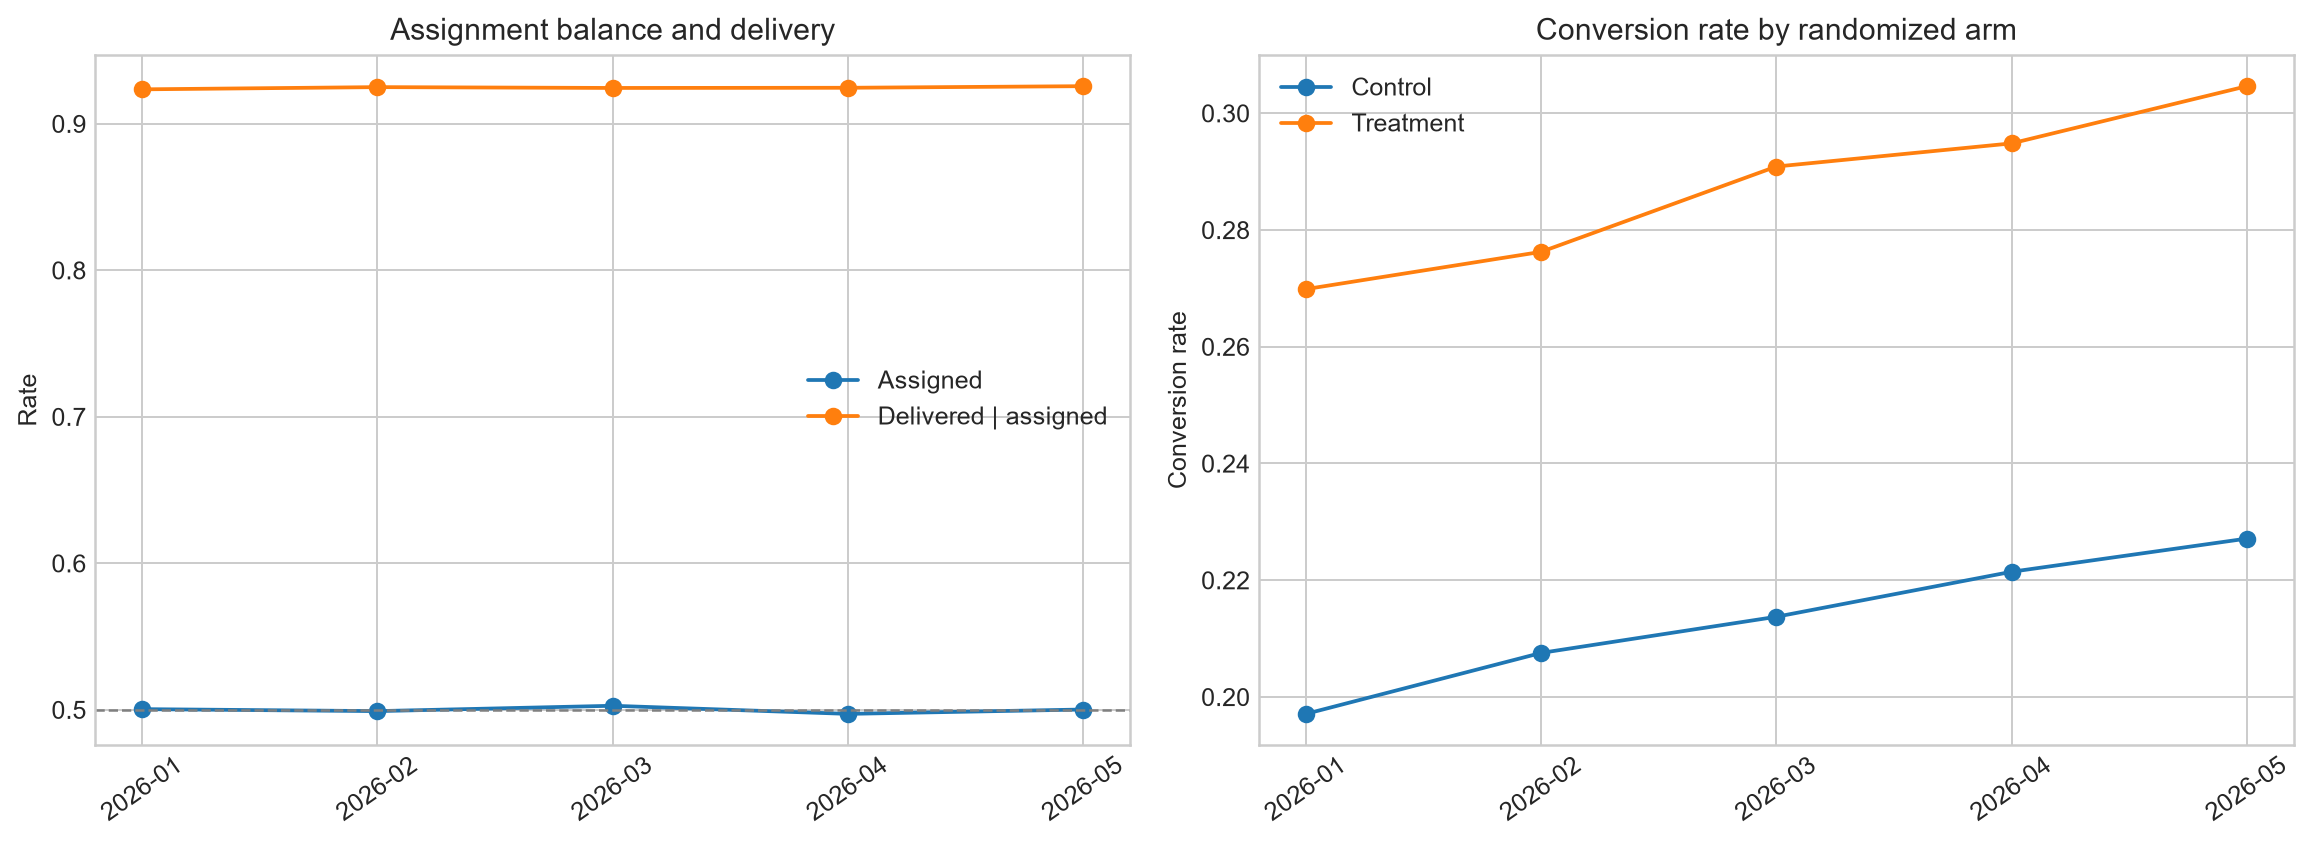

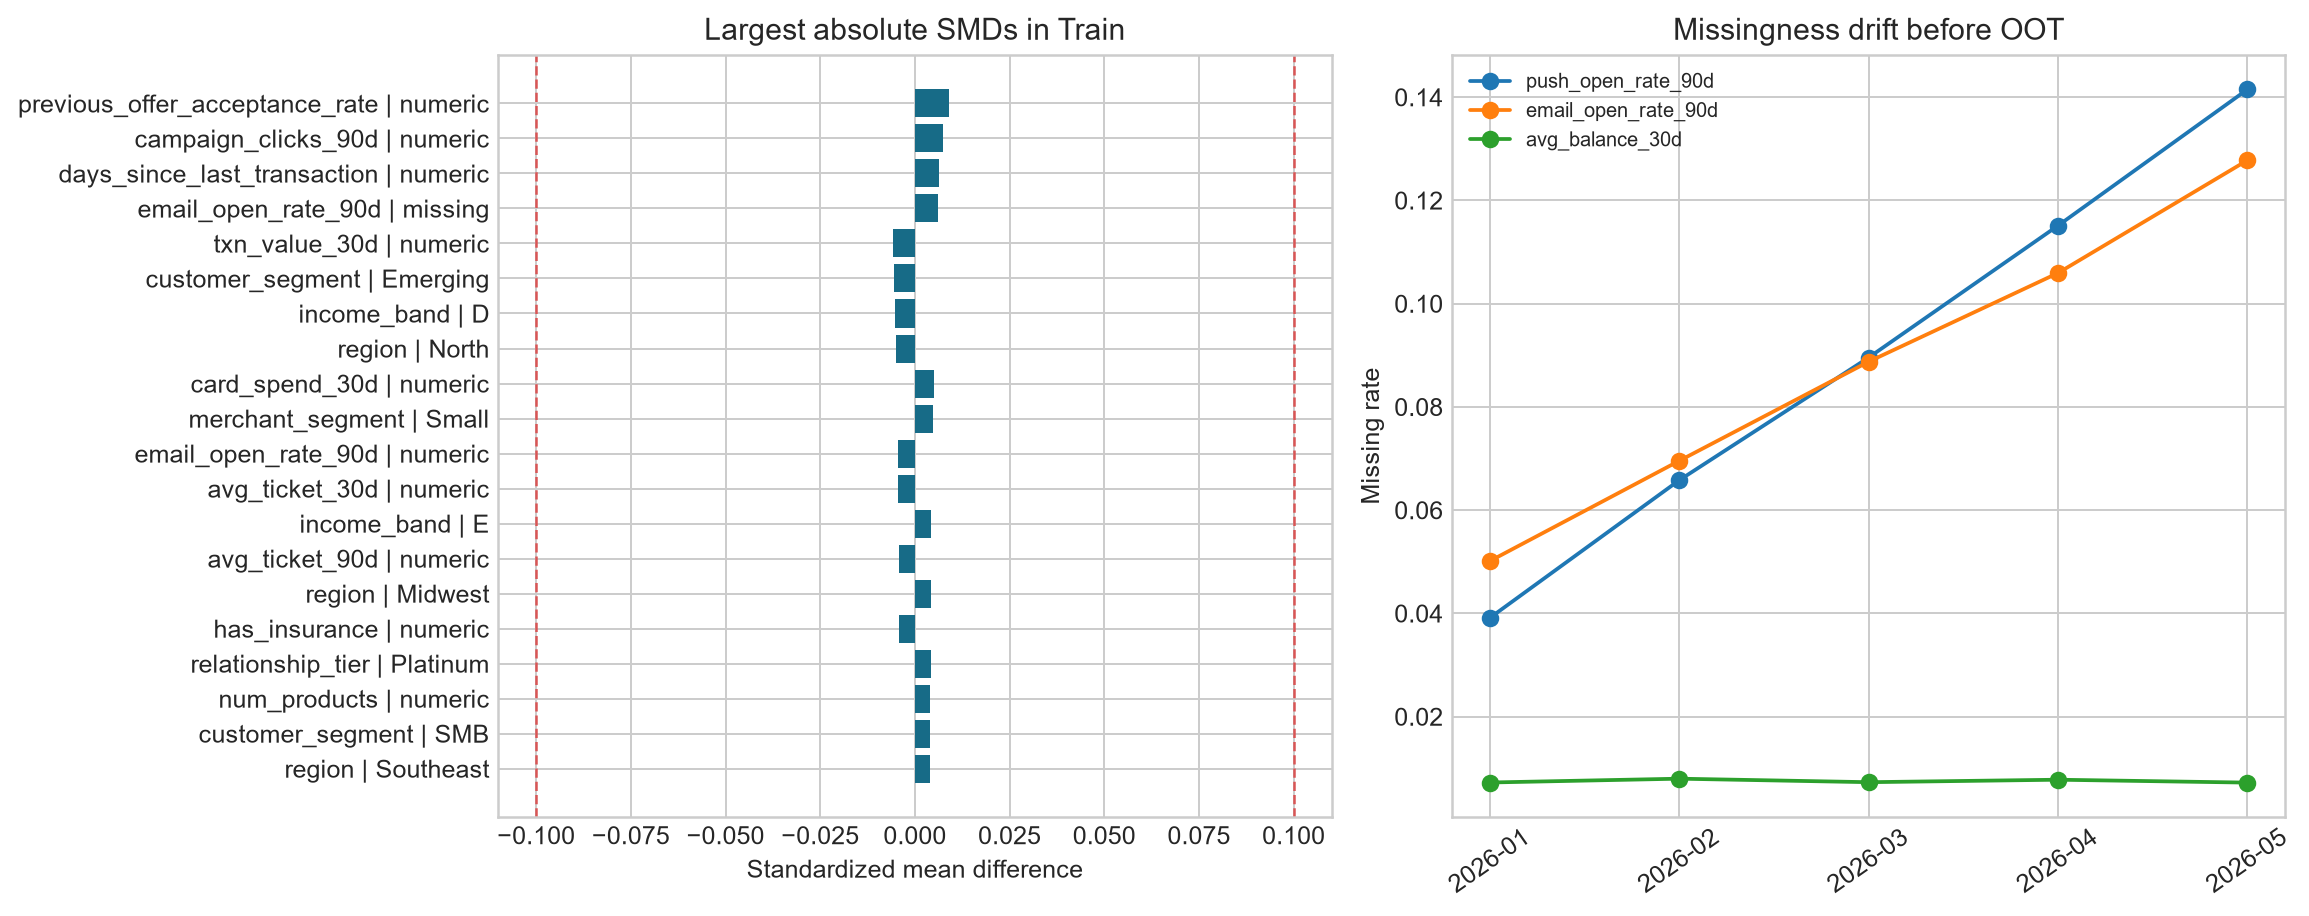

,max_abs_smd_train,delivery_rate_among_assigned
0,0.009015,0.924648


In [5]:
display(Image(filename=str(PROJECT_ROOT / "outputs" / "figures" / "01_development_experiment_design.png")))
display(Image(filename=str(PROJECT_ROOT / "outputs" / "figures" / "02_balance_and_missing_drift.png")))

balance = pd.read_csv(PROJECT_ROOT / "outputs" / "tables" / "train_randomization_balance_smd.csv")
non_compliance = pd.read_csv(PROJECT_ROOT / "outputs" / "tables" / "development_non_compliance_summary.csv")
pd.DataFrame({
    "max_abs_smd_train": [balance["abs_smd"].max()],
    "delivery_rate_among_assigned": [non_compliance.loc[non_compliance["metric"].eq("delivery_rate_among_assigned"), "value"].iloc[0]],
})

**Análise/Interpretação:** o tratamento ficou próximo de 50% em todas as ondas, e o maior SMD no Train ficou abaixo de 0,01, compatível com boa randomização. A entrega ocorre para cerca de 92% dos tratados. Essa falha operacional é relevante para implementação, mas não autoriza análise per-protocol como efeito causal principal.

## 8. Baseline causal: difference in means / ITT

Antes de modelar heterogeneidade, estimamos `E[Y|T=1] - E[Y|T=0]` e intervalo de confiança. Esse baseline responde se há efeito médio, não quem deve ser tratado.

In [6]:
wave_summary = pd.read_csv(PROJECT_ROOT / "outputs" / "tables" / "development_experiment_summary_by_wave.csv")
wave_summary[["campaign_wave", "n", "treatment_rate", "control_conversion_rate", "treated_conversion_rate", "itt", "itt_ci_low", "itt_ci_high"]]

,campaign_wave,n,treatment_rate,control_conversion_rate,treated_conversion_rate,itt,itt_ci_low,itt_ci_high
0,2026-01,50000,0.50046,0.197101,0.269872,0.072770,0.065382,0.080159
1,2026-02,50000,0.49910,0.207546,0.276257,0.068711,0.061227,0.076195
2,2026-03,50000,0.50276,0.213740,0.290874,0.077135,0.069552,0.084717
3,2026-04,50000,0.49722,0.221449,0.294839,0.073391,0.065744,0.081037
4,2026-05,50000,0.50020,0.227131,0.304638,0.077507,0.069792,0.085222


**Análise/Interpretação:** o ITT é positivo e estável nas ondas de desenvolvimento, aproximadamente 7 a 8 pontos percentuais. O efeito médio justifica investigar heterogeneidade, mas tratar todos os clientes ainda ignora custo e possível efeito negativo individual.

## 9. Feature engineering e preprocessing

O conjunto inclui somente covariáveis pré-tratamento. Sentinelas recebem flags explícitas; razões 30d/90d, intensidade Pix, engajamento anterior e transformações `log1p` representam comportamento. Imputação e encoding aprendem parâmetros exclusivamente no Train.

Zeros de saldo e ausência de produto permanecem zeros quando têm significado econômico. Missing digital permanece observável por indicadores do imputador.

## 10. Propensity benchmark e modelos de uplift

- **Top Propensity:** LightGBM treinado apenas entre tratados para estimar `P(Y=1|T=1,X)`.
- **S-Learner:** um outcome model recebe tratamento como feature.
- **T-Learner / Two-model:** modelos separados por braço.
- **X-Learner:** nuisance models com cross-fitting em três folds e regressão dos efeitos imputados.

Causal Forest e Uplift Tree não foram executados porque `econml` e `causalml` não estavam disponíveis. A ausência é registrada, não substituída por uma implementação com nome inadequado.

In [7]:
availability = pd.read_csv(PROJECT_ROOT / "outputs" / "tables" / "model_availability.csv")
availability

,method,implemented,reason
0,S-Learner,True,LightGBM outcome model with treatment indicator
1,T-Learner / Two-model,True,Separate LightGBM outcome models by randomized...
2,X-Learner,True,Three-fold cross-fitted imputed treatment effects
3,Causal Forest,False,econml not available in the execution environment
4,Uplift Tree,False,causalml not available in the execution enviro...


## 11. Validação, Qini, AUUC e escolha do champion

O champion é definido na onda 5 pelo maior Qini coefficient; AUUC e Uplift@20% funcionam como desempate. `Uplift@k` é a diferença observada entre braços randomizados dentro do topo do ranking. Qini/AUUC usam ganho incremental cumulativo por cliente elegível.

,auuc,qini_coefficient,model,uplift_at_10pct,uplift_at_20pct,mean_estimated_cate,predicted_negative_effect_share
0,0.022901,0.003516,S-Learner,0.134628,0.122207,0.070104,0.00352
1,0.022682,0.003298,X-Learner,0.126682,0.113636,0.073066,0.00804
2,0.022127,0.002742,T-Learner,0.114642,0.105646,0.073008,0.03554


Champion congelado: S-Learner


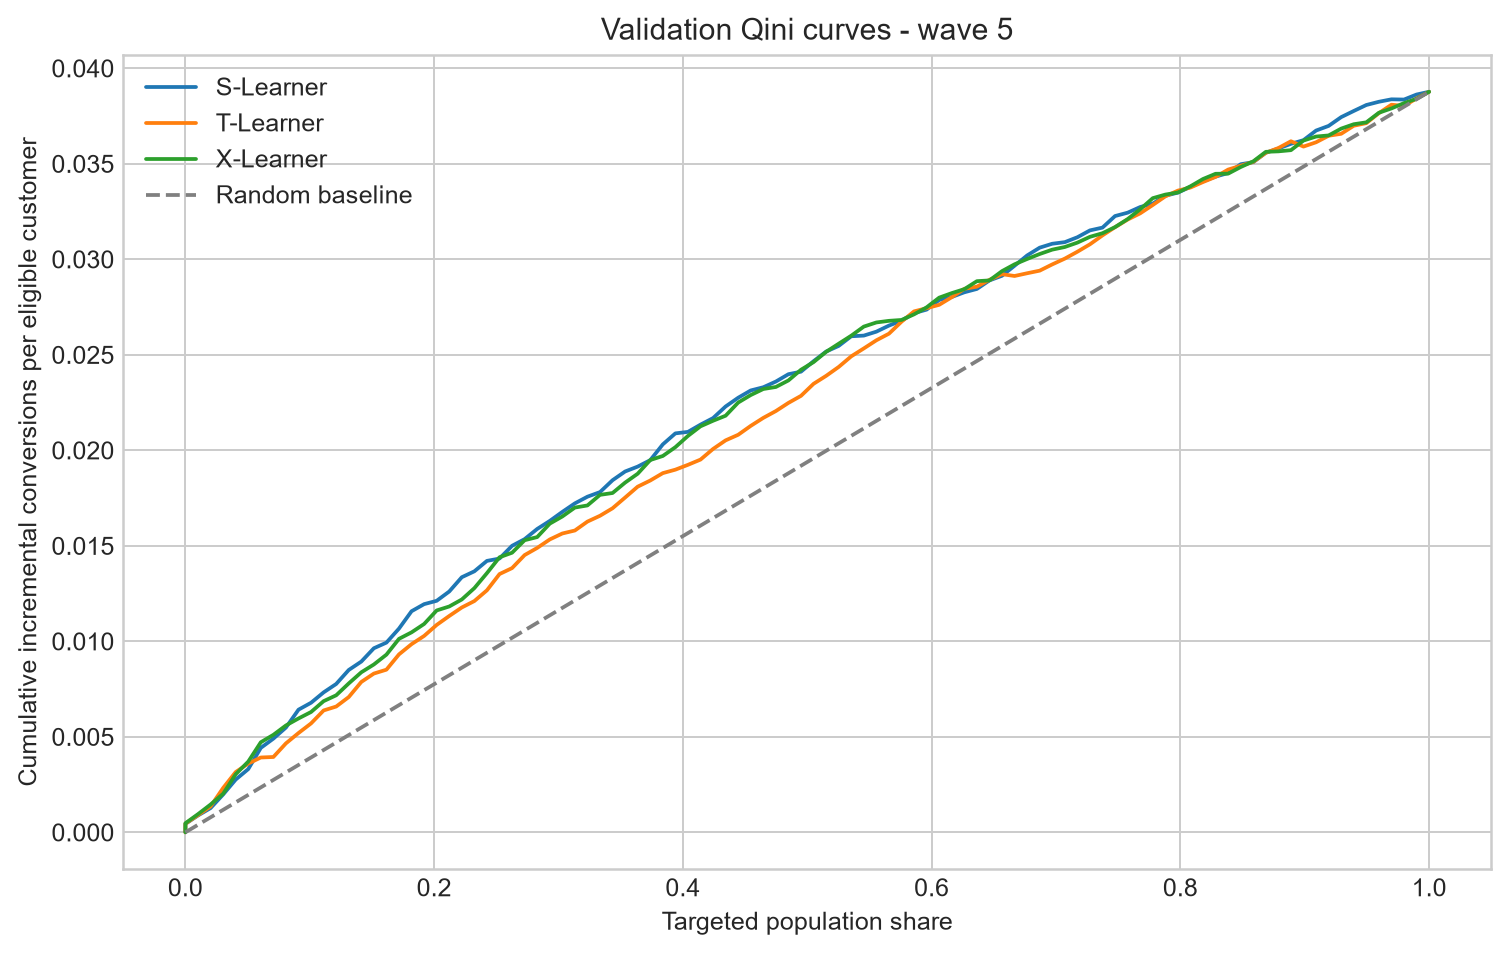

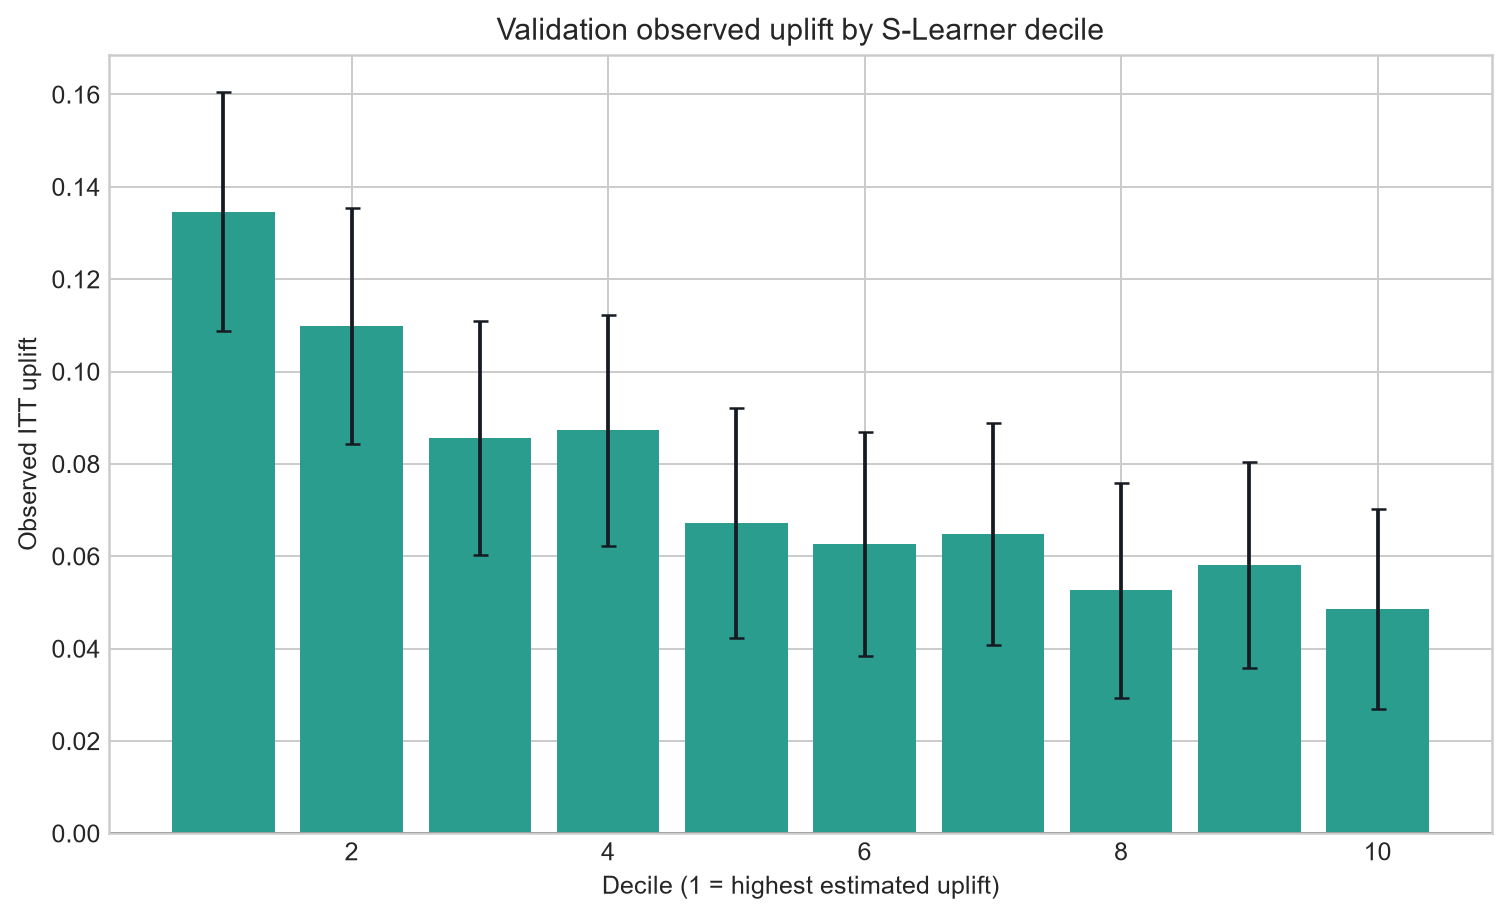

In [8]:
validation_metrics = pd.read_csv(PROJECT_ROOT / "outputs" / "metrics" / "validation_model_comparison.csv")
freeze = json.loads((PROJECT_ROOT / "outputs" / "metrics" / "champion_freeze_record.json").read_text(encoding="utf-8"))
display(validation_metrics)
print("Champion congelado:", freeze["champion"])
display(Image(filename=str(PROJECT_ROOT / "outputs" / "figures" / "03_validation_qini_curves.png")))
display(Image(filename=str(PROJECT_ROOT / "outputs" / "figures" / "04_validation_uplift_deciles.png")))

**Análise/Interpretação:** o S-Learner foi escolhido antes do OOT. Na Validation, o topo de 20% apresenta uplift observado de aproximadamente 12,2 p.p., acima do ITT médio. A ordenação por decis melhora de forma geral, embora intervalos por decil lembrem que efeitos individuais não são diretamente observáveis.

## 12. Explicabilidade da heterogeneidade

A importância global descreve quais covariáveis o learner usa para construir o score. Ela não prova mecanismo causal de cada feature e não deve ser interpretada como efeito de intervir na covariável.

,feature,importance,importance_share
0,txn_count_30d,27178.225726,0.230454
1,txn_value_90d,16424.568688,0.139270
2,app_sessions_30d,12663.061140,0.107375
3,product_page_views_30d,5523.439299,0.046835
4,credit_limit,5399.037890,0.045780
5,previous_offer_acceptance_rate,4525.403824,0.038373
6,txn_count_90d,4121.155052,0.034945
7,avg_balance_30d,3908.786215,0.033144
8,app_sessions_90d,3574.692238,0.030311
9,days_since_last_transaction,3387.933126,0.028727


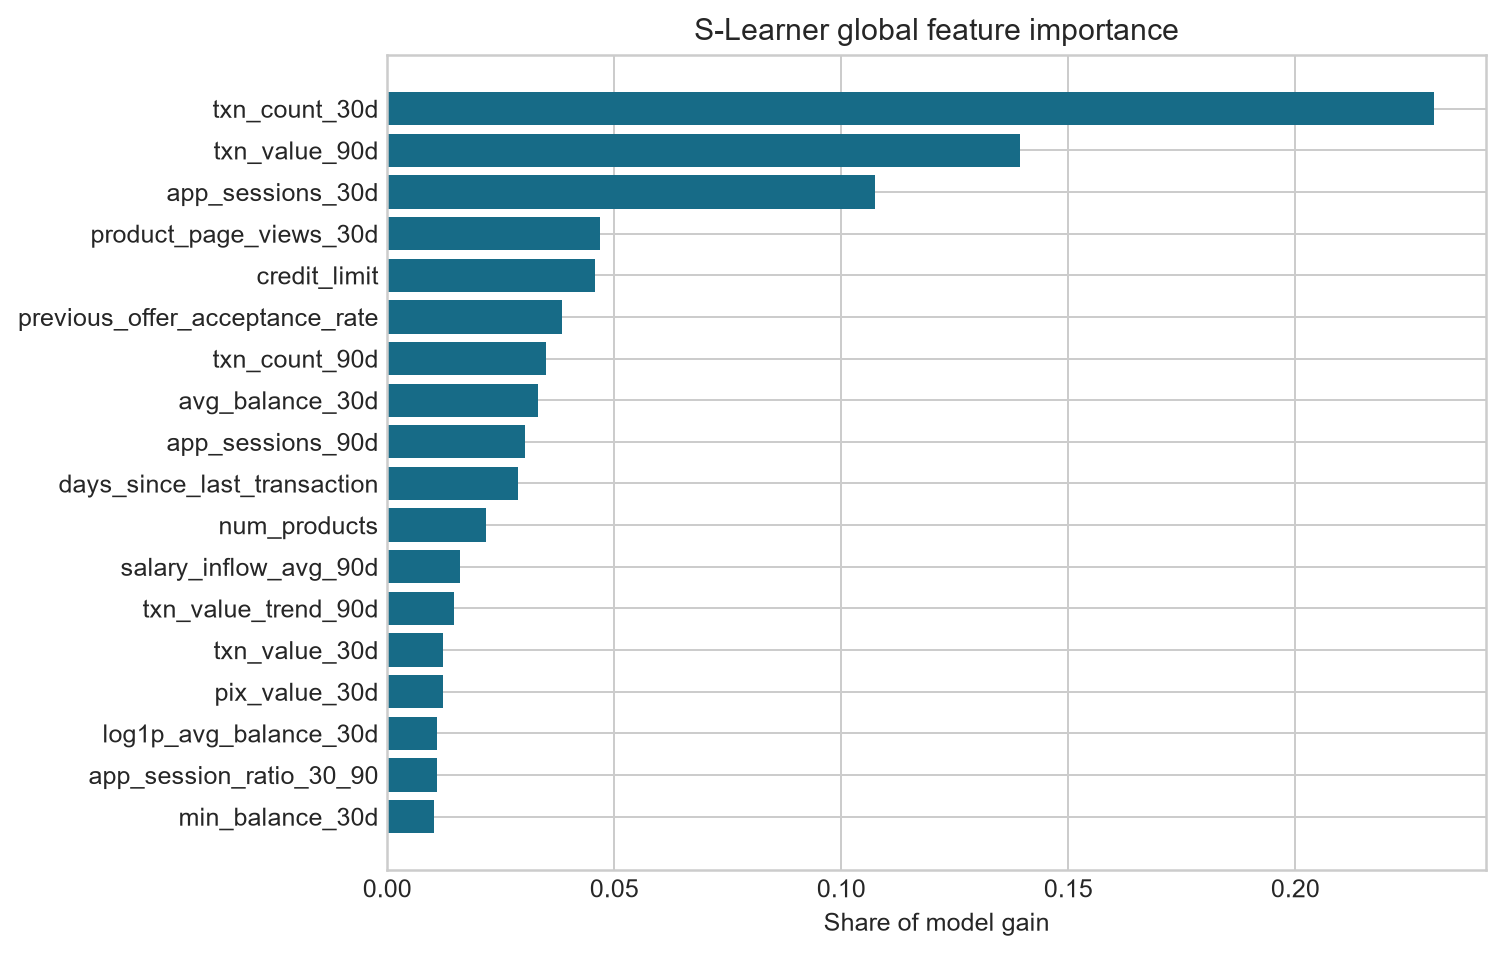

In [9]:
importance = pd.read_csv(PROJECT_ROOT / "outputs" / "tables" / "champion_feature_importance.csv")
display(importance.head(15))
display(Image(filename=str(PROJECT_ROOT / "outputs" / "figures" / "09_champion_feature_importance.png")))

## 13. OOT Final Test - onda 6

Depois do freeze, o champion é aplicado uma única vez à onda 6. O teste final mede generalização temporal de ITT, ranking, Qini, AUUC, uplift no topo e estabilidade por segmento.

,auuc,qini_coefficient,model,uplift_at_10pct,uplift_at_20pct,mean_estimated_cate,predicted_negative_effect_share,sample
0,0.022163,0.002971,S-Learner,0.12533,0.108327,0.070295,0.0041,OOT wave 6


,quantile,n,treated_rate,control_rate,observed_uplift,ci_low,ci_high,mean_estimated_cate
0,1,5000,0.409412,0.284082,0.125330,0.099188,0.151472,0.137026
1,2,5000,0.374950,0.283811,0.091139,0.065210,0.117069,0.110679
2,3,5000,0.372319,0.271253,0.101065,0.075300,0.126830,0.094903
3,4,5000,0.339017,0.249901,0.089116,0.063945,0.114287,0.081872
4,5,5000,0.327677,0.252673,0.075004,0.049914,0.100093,0.070572
5,6,5000,0.299879,0.244938,0.054941,0.030296,0.079585,0.060532
6,7,5000,0.292880,0.241297,0.051583,0.027082,0.076083,0.051394
7,8,5000,0.268645,0.221868,0.046777,0.022955,0.070599,0.042829
8,9,5000,0.257822,0.180606,0.077216,0.054390,0.100041,0.033867
9,10,5000,0.227731,0.172688,0.055043,0.032899,0.077188,0.019277


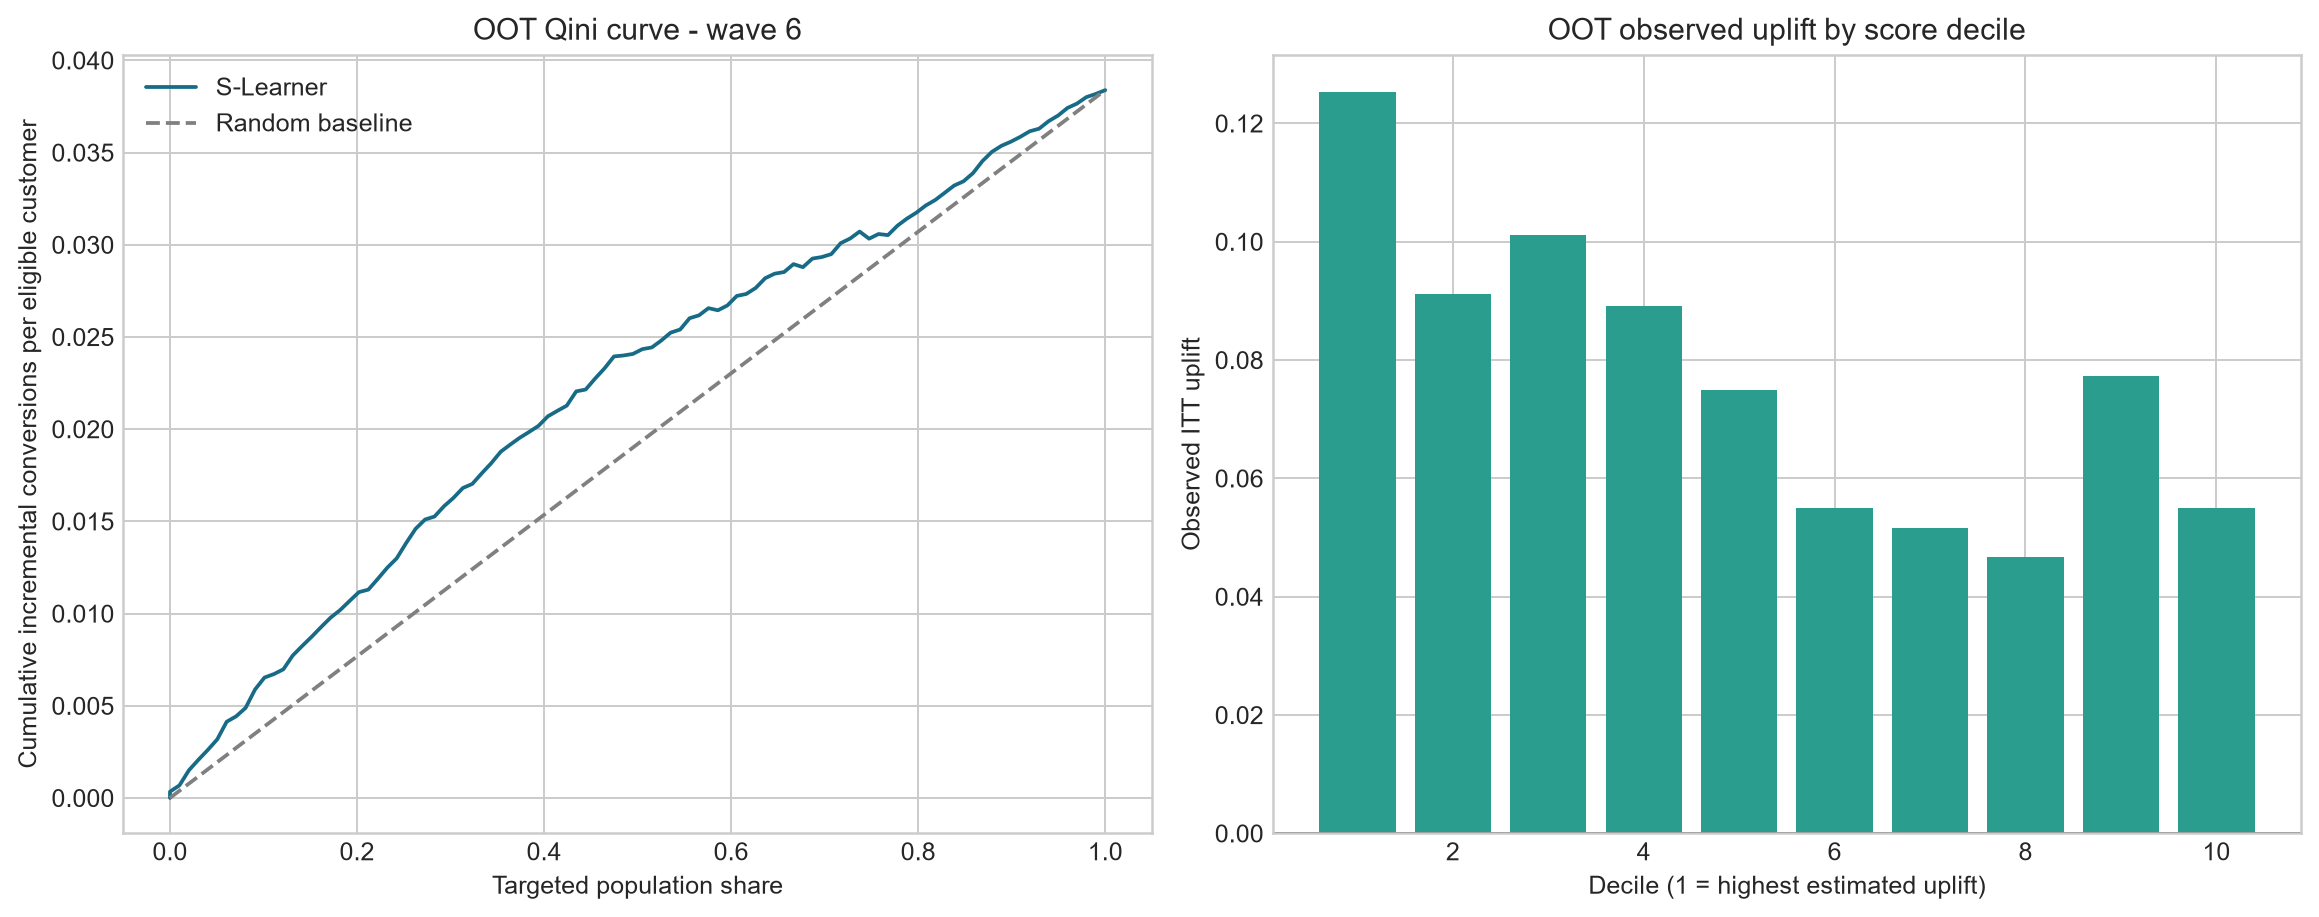

In [10]:
oot_metrics = pd.read_csv(PROJECT_ROOT / "outputs" / "metrics" / "oot_champion_metrics.csv")
oot_deciles = pd.read_csv(PROJECT_ROOT / "outputs" / "tables" / "oot_uplift_by_decile.csv")
display(oot_metrics)
display(oot_deciles)
display(Image(filename=str(PROJECT_ROOT / "outputs" / "figures" / "05_oot_qini_and_deciles.png")))

**Análise/Interpretação:** o ITT consolidado do OOT é 7,70 p.p. (IC95%: 6,91 a 8,48 p.p.). O champion preserva ganho de ranking: Uplift@20% de 10,83 p.p. e Qini positivo. O resultado não autoriza trocar o champion retrospectivamente.

## 14. Random 20% versus Top Propensity 20% versus Top Uplift 20%

As políticas usam capacidade idêntica. Incremental conversions, revenue e margin são diferenças randomizadas escaladas para toda a audiência. O custo esperado usa o custo médio observado entre tratados selecionados. Portanto, a comparação é incremental, não soma de conversões brutas.

,policy,n_selected,treated_conversion_rate,control_conversion_rate,uplift,incremental_conversions,incremental_margin,campaign_cost,net_incremental_value,roi
0,Random 20%,10000.0,0.317155,0.240953,0.076202,762.024207,58597.318575,4086.699667,54510.618908,13.339004
1,Top Propensity 20%,10000.0,0.446079,0.357214,0.088866,888.656866,77440.943739,4130.135053,73310.808686,17.750221
2,Top Uplift 20%,10000.0,0.392273,0.283946,0.108327,1083.272110,78287.244645,4109.107037,74178.137608,18.052131


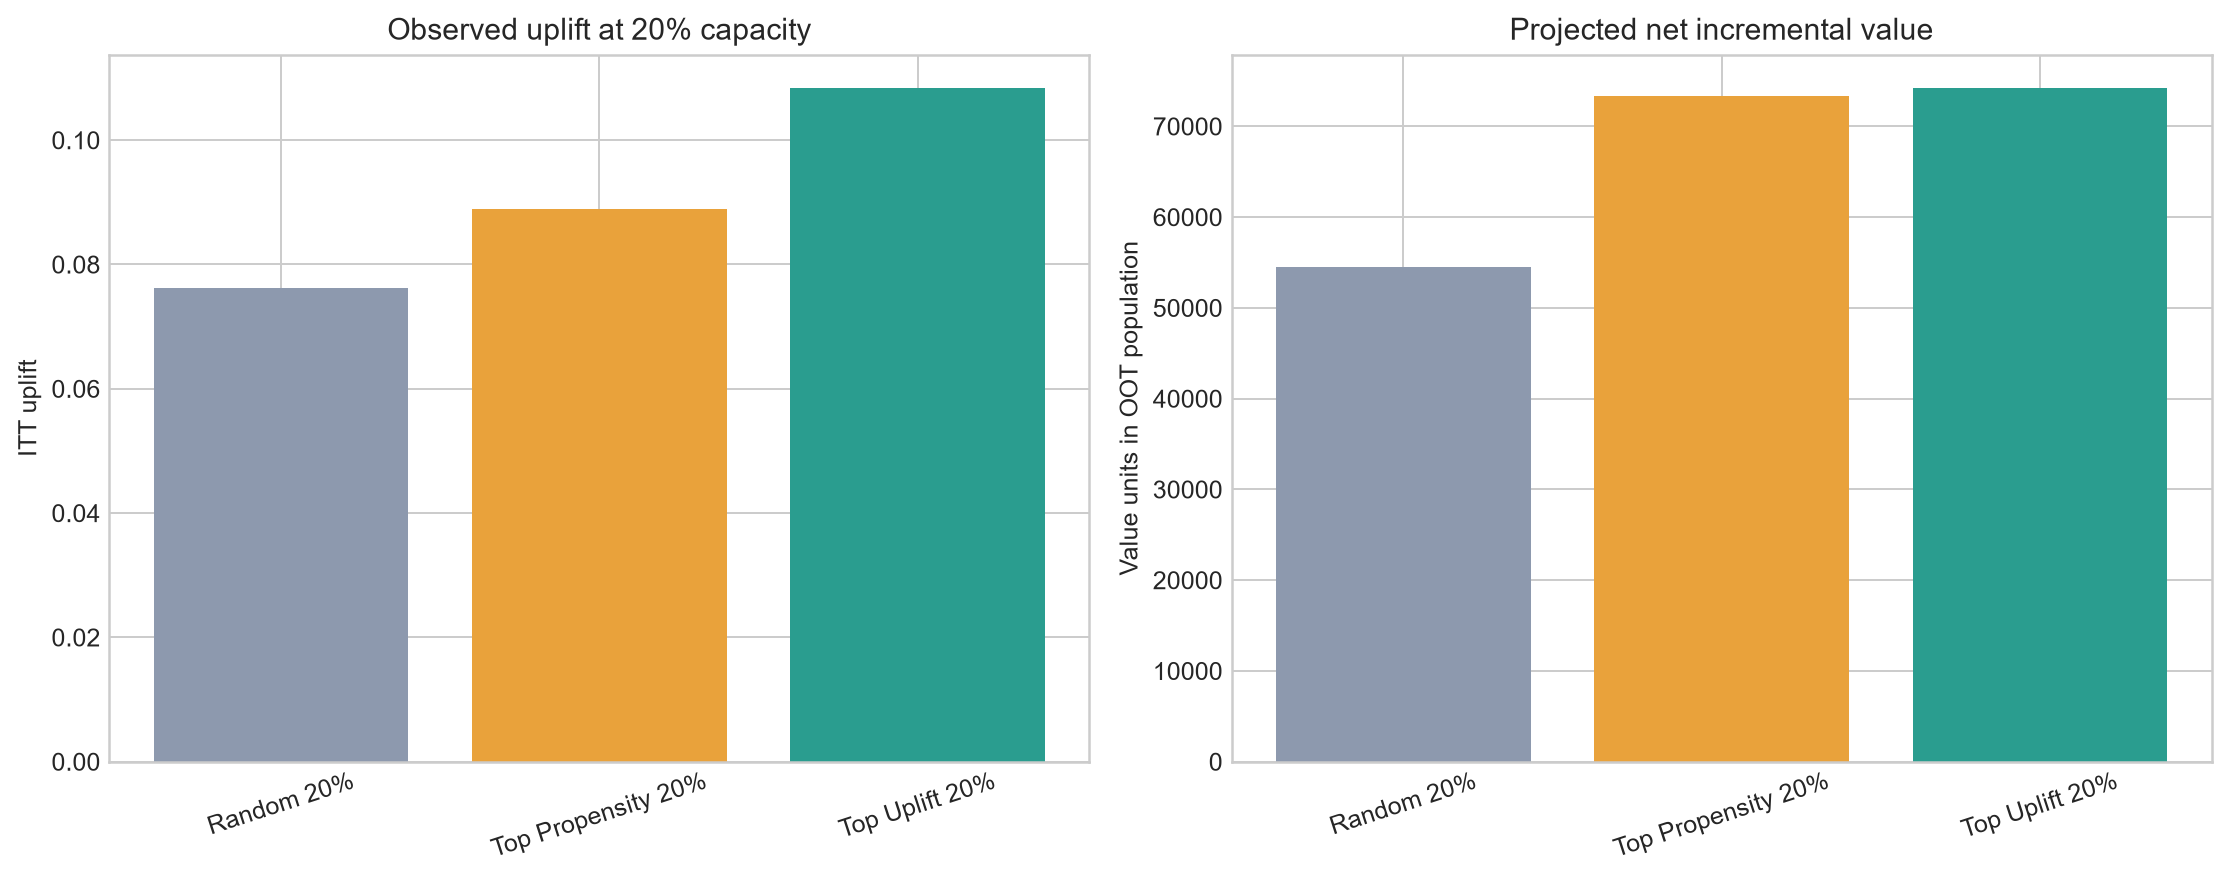

In [11]:
policies = pd.read_csv(PROJECT_ROOT / "outputs" / "tables" / "oot_policy_comparison.csv")
columns = [
    "policy", "n_selected", "treated_conversion_rate", "control_conversion_rate", "uplift",
    "incremental_conversions", "incremental_margin", "campaign_cost", "net_incremental_value", "roi"
]
display(policies[columns])
display(Image(filename=str(PROJECT_ROOT / "outputs" / "figures" / "06_oot_policy_comparison.png")))

**Análise/Interpretação:** Top Uplift produz cerca de 1.083 conversões incrementais na audiência de 10 mil clientes, contra aproximadamente 889 no Top Propensity e 762 no Random. O valor líquido supera Random de forma material. A vantagem econômica sobre Propensity é positiva, mas estreita, porque os grupos diferem também na margem média; isso recomenda otimizar diretamente valor incremental na próxima iteração.

## 15. Por que propensity não é uplift

Propensity estima conversão sob campanha; uplift estima a diferença entre os outcomes potenciais. Sure Things podem ter alta propensity e baixo ganho incremental. Persuadables podem ter propensity moderada e alto CATE. Sleeping Dogs podem apresentar efeito negativo.

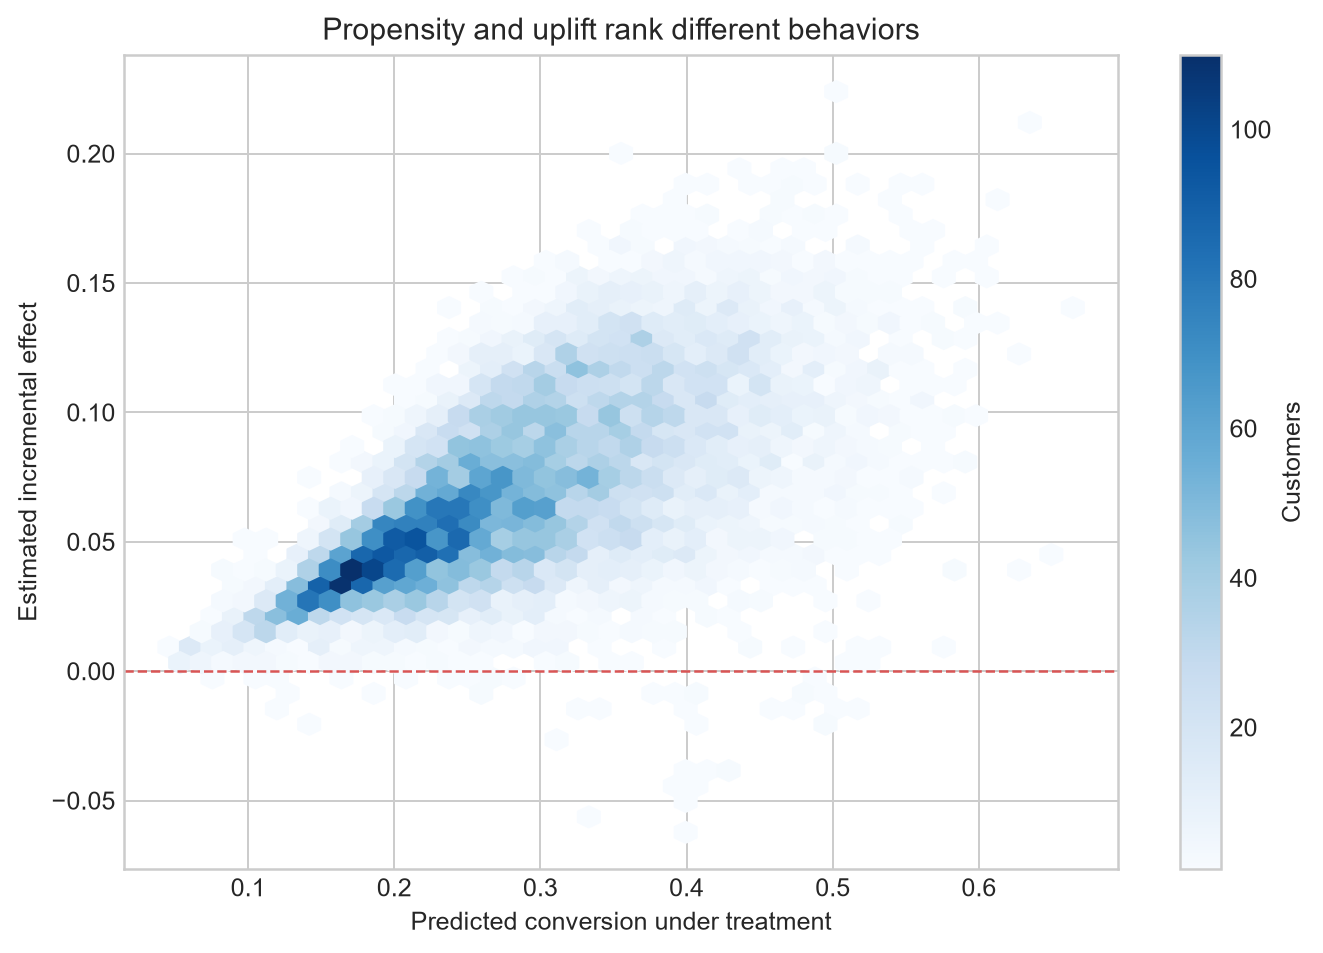

,spearman_propensity_vs_uplift,top20_audience_overlap,predicted_negative_effect_share
0,0.665368,0.4967,0.0041


In [12]:
display(Image(filename=str(PROJECT_ROOT / "outputs" / "figures" / "07_propensity_vs_uplift.png")))
summary = json.loads((PROJECT_ROOT / "outputs" / "metrics" / "executive_summary.json").read_text(encoding="utf-8"))
pd.DataFrame({
    "spearman_propensity_vs_uplift": [summary["oot"]["propensity_uplift_spearman"]],
    "top20_audience_overlap": [summary["oot"]["top20_audience_overlap"]],
    "predicted_negative_effect_share": [summary["oot"]["predicted_negative_effect_share"]],
})

**Análise/Interpretação:** os scores têm correlação apenas parcial e compartilham aproximadamente metade da audiência Top 20%. Os perfis Persuadable, Sure Thing, Lost Cause e Sleeping Dog são construções latentes; o dataset público não fornece rótulos individuais desses grupos.

## 16. Segmentos, risco de dano e estabilidade

Análises segmentadas são diagnósticas. Elas verificam concentração de efeito e risco de dano, sem substituir o experimento nem transformar segmentos comerciais em tipos causais observáveis.

,segment_variable,segment,n,observed_itt,ci_low,ci_high,mean_estimated_cate,predicted_negative_effect_share
4,customer_segment,SMB,4680,0.066779,0.040412,0.093146,0.072252,0.007265
0,customer_segment,Affluent,5995,0.072528,0.049779,0.095277,0.072861,0.002168
3,customer_segment,MicroMerchant,9266,0.074397,0.055980,0.092814,0.069883,0.007123
2,customer_segment,Mass,20478,0.079358,0.067304,0.091412,0.069546,0.002881
1,customer_segment,Emerging,9581,0.083518,0.065630,0.101406,0.069732,0.003444
6,merchant_flag,1,13946,0.071749,0.056647,0.086851,0.070678,0.007171
5,merchant_flag,0,36054,0.079216,0.070062,0.088370,0.070147,0.002912
9,region,Northeast,12098,0.070309,0.054328,0.086290,0.071237,0.003968
10,region,South,7439,0.075824,0.055506,0.096142,0.069496,0.002689
11,region,Southeast,21394,0.076195,0.064244,0.088147,0.070010,0.004581


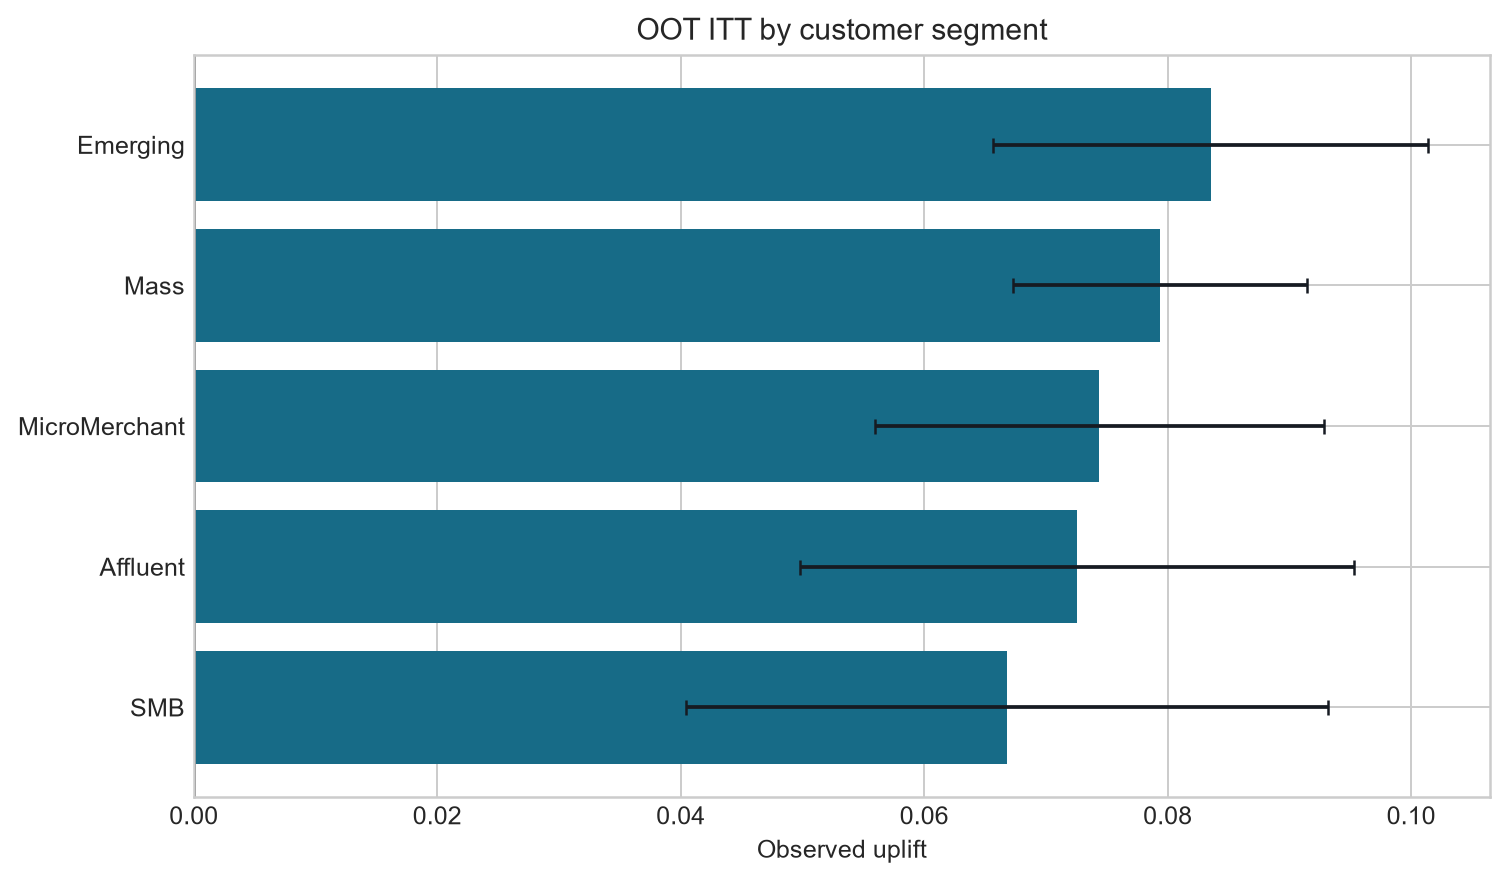

In [13]:
segments = pd.read_csv(PROJECT_ROOT / "outputs" / "tables" / "oot_segment_effects.csv")
display(segments.sort_values(["segment_variable", "observed_itt"]))
display(Image(filename=str(PROJECT_ROOT / "outputs" / "figures" / "08_oot_segment_effects.png")))

## 17. Limitações causais e riscos metodológicos

- **SUTVA/interference:** clientes podem influenciar outros ou receber estímulos concorrentes.
- **Non-compliance:** ITT mede efeito da atribuição, diluído por falhas de entrega.
- **Generalização temporal:** drift de população, baseline e execução pode alterar CATE.
- **Tratamento binário:** canais diferentes são execução pós-assignment; causalidade por canal exige desenho multi-treatment.
- **Múltiplas campanhas:** fadiga, carryover e tratamentos simultâneos podem violar a janela simples.
- **CATE individual:** não é observado; performance deve ser julgada por políticas e grupos randomizados.
- **Policy overfitting:** capacidade e função econômica precisam ser congeladas antes de novos testes.

## 18. Monitoramento e validação em produção

1. Manter holdout randomizado persistente e registrar assignment, delivery e custo.
2. Monitorar treatment rate, delivery rate, covariate balance e overlap.
3. Acompanhar PSI de covariáveis, distribuição de CATE e participação com CATE negativo.
4. Medir ITT, Qini/AUUC, Uplift@20%, policy value e ROI por onda.
5. Reestimar intervalos de confiança e avaliar segmentos protegidos/operacionais.
6. Promover challenger somente em janela futura previamente definida.
7. Evoluir de CATE de conversão para CATE de margem líquida.

## 19. Conclusão executiva

- A randomização está balanceada e sustenta identificação causal do ITT.
- A campanha gera efeito médio positivo e estatisticamente relevante.
- O S-Learner escolhido na Validation mantém ganho de ranking no OOT.
- Top Uplift 20% supera Random e Top Propensity em conversões incrementais.
- O ganho econômico sobre Propensity é modesto; a próxima versão deve modelar valor incremental líquido diretamente.
- A política deve ser confirmada em novo experimento randomizado com holdout.

> **Propensity prioriza clientes, mas ainda não demonstra causalidade.** Uplift modeling usa a variação experimental para priorizar efeito incremental, mas sua política continua dependente das hipóteses causais e de validação prospectiva.